# Bank Term-Deposit Campaign: Funnel & Conversion Analysis

**Data:** Portuguese bank direct-marketing phone campaigns (Moro, Laureano & Cortez, 2011), May 2008 – Nov 2010. 
Each row is one client contacted by phone; `y` = subscribed to a term deposit.

**What this notebook does**
1. Cleans and structures the data (validation, dates, derived fields)
2. Maps the call-centre data onto a marketing funnel
3. Measures stage-to-stage conversion and drop-off
4. Compares channels, campaign waves, time periods and audience segments (with significance tests)
5. Quantifies the opportunity and gives recommendations

> **Citation:** S. Moro, R. Laureano and P. Cortez. *Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.* ESM'2011, pp. 117-121.

### How the funnel is defined
The dataset has no web-traffic or CRM lead-status fields, so the funnel is built from **call outcomes**. 
The stage thresholds are proxies and are configurable in the *Config* cell.

| Stage | Definition | Marketing analogue |
|---|---|---|
| 1. Contacted | every row | Traffic / audience reached |
| 2. Engaged | call lasted ≥ `ENGAGED_SEC` | Lead (client stayed on the line beyond a brush-off) |
| 3. Qualified | call lasted ≥ `QUALIFIED_SEC` | Sales-qualified lead (real conversation) |
| 4. Subscribed | `y == "yes"` | Customer |

**Traffic-to-lead** = Engaged / Contacted. **Lead-to-customer** = Subscribed / Engaged.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# ---------------- Config ----------------
DATA_DIR = Path("/mnt/user-data/uploads")     # change if running elsewhere
if not (DATA_DIR / "bank-full.csv").exists():
    DATA_DIR = Path(".")
ENGAGED_SEC   = 60     # funnel stage 2 threshold (seconds)
QUALIFIED_SEC = 180    # funnel stage 3 threshold (seconds)
MIN_N         = 200    # ignore segments smaller than this in rankings
ALPHA         = 0.05

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 50
PCT = mtick.PercentFormatter(1.0, decimals=0)

## 1. Load & clean

In [2]:
raw = pd.read_csv(DATA_DIR / "bank-full.csv", sep=";")
sample = pd.read_csv(DATA_DIR / "bank.csv", sep=";")      # 10% random sample, used only for reconciliation
print("bank-full:", raw.shape, "| bank (sample):", sample.shape)
raw.head()

bank-full: (45211, 17) | bank (sample): (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df = raw.copy()

# --- standardise text columns
obj_cols = df.select_dtypes("object").columns
for c in obj_cols:
    df[c] = df[c].str.strip().str.lower()

# --- data-quality report
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "n_unique": df.nunique(),
    "'unknown' values": [(df[c] == "unknown").sum() if c in obj_cols else 0 for c in df.columns],
})
print(f"Duplicate rows: {df.duplicated().sum()}")
display(quality)

Duplicate rows: 0


,dtype,missing,n_unique,'unknown' values
age,int64,0,77,0
job,str,0,12,288
marital,str,0,3,0
education,str,0,4,1857
default,str,0,2,0
balance,int64,0,7168,0
housing,str,0,2,0
loan,str,0,2,0
contact,str,0,3,13020
day,int64,0,31,0


In [4]:
# --- validity checks
checks = {
    "age outside 18-100":        ((df.age < 18) | (df.age > 100)).sum(),
    "day outside 1-31":          ((df.day < 1) | (df.day > 31)).sum(),
    "duration == 0 (no call)":   (df.duration == 0).sum(),
    "campaign < 1":              (df.campaign < 1).sum(),
    "pdays=-1 but previous>0":   ((df.pdays == -1) & (df.previous > 0)).sum(),
    "pdays>=0 but previous==0":  ((df.pdays >= 0) & (df.previous == 0)).sum(),
}
print(pd.Series(checks, name="rows failing").to_string())

# --- structure / derive fields
MONTHS = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
df["month_num"] = df.month.map({m: i + 1 for i, m in enumerate(MONTHS)})

# The file is ordered by date (May-2008 .. Nov-2010) but has no year column.
# A new year starts whenever the month number falls vs. the previous row.
year = 2008 + (df.month_num.diff().fillna(0) < 0).cumsum()
df["year"] = year
df["period"] = pd.to_datetime(dict(year=df.year, month=df.month_num, day=1))
df["quarter"] = df.period.dt.to_period("Q").astype(str)
df["half_label"] = df.period.dt.strftime("%Y-%m")

df["converted"]      = (df.y == "yes").astype(int)
df["prev_contacted"] = (df.pdays != -1)
df["pdays"]          = df.pdays.replace(-1, np.nan)       # -1 is a flag, not a number
df["poutcome"]       = df.poutcome.replace({"unknown": "not previously contacted"}).where(df.prev_contacted, "not previously contacted")

# --- binned dimensions
df["age_band"] = pd.cut(df.age, [17, 24, 34, 44, 54, 64, 100],
                        labels=["18-24","25-34","35-44","45-54","55-64","65+"])
df["balance_band"] = pd.cut(df.balance, [-np.inf, 0, 500, 1500, 5000, np.inf],
                            labels=["<=0","1-500","501-1,500","1,501-5,000",">5,000"])
df["attempts_band"] = pd.cut(df.campaign, [0, 1, 2, 3, 5, 10, np.inf],
                             labels=["1","2","3","4-5","6-10","11+"])
df["duration_band"] = pd.cut(df.duration, [-1, 30, ENGAGED_SEC-1, QUALIFIED_SEC-1, 300, 600, np.inf],
                             labels=["0-30s", f"31-{ENGAGED_SEC-1}s", f"{ENGAGED_SEC}-{QUALIFIED_SEC-1}s","180-300s","300-600s","600s+"])

# --- funnel flags
df["s1_contacted"]  = 1
df["s2_engaged"]    = (df.duration >= ENGAGED_SEC).astype(int)
df["s3_qualified"]  = (df.duration >= QUALIFIED_SEC).astype(int)
df["s4_subscribed"] = df.converted

# --- reconcile: sample should be a subset of the full file with a similar conversion rate
merged = sample.merge(raw.drop_duplicates(), how="left", indicator=True)
print(f"\nSample rows found in full file: {(merged._merge=='both').mean():.1%}")
print(f"Conversion  full: {df.converted.mean():.2%} | sample: {(sample.y=='yes').mean():.2%}")
print("Years inferred:", df.groupby('year').period.agg(['min','max']).to_string())

age outside 18-100          0
day outside 1-31            0
duration == 0 (no call)     3
campaign < 1                0
pdays=-1 but previous>0     0
pdays>=0 but previous==0    0



Sample rows found in full file: 100.0%
Conversion  full: 11.70% | sample: 11.52%
Years inferred:             min        max
year                      
2008 2008-05-01 2008-12-01
2009 2009-01-01 2009-12-01
2010 2010-01-01 2010-11-01


**Cleaning notes**
- No missing values or duplicates. `unknown` is a *real category* in `job`, `education`, `contact` and `poutcome`; it is kept as its own value (not dropped) and is meaningful for `contact` and `poutcome` (see below).
- `pdays = -1` means "never contacted before"; it is converted to `NaN` and a boolean `prev_contacted` is created.
- A `year` field was reconstructed from the date ordering of the file, so months can be compared across years.
- `bank.csv` is a random 10% subset of `bank-full.csv`. It is used only to reconcile; all results use the full file.

## 2. The funnel: overall conversion and drop-off

In [5]:
STAGES = [("1. Contacted","s1_contacted"), ("2. Engaged","s2_engaged"),
          ("3. Qualified","s3_qualified"), ("4. Subscribed","s4_subscribed")]

def wilson(k, n, z=1.96):
    """Wilson score interval for a proportion."""
    k, n = np.asarray(k, float), np.asarray(n, float)
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / d
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return centre - half, centre + half

def funnel_table(d):
    counts = [d[c].sum() for _, c in STAGES]
    t = pd.DataFrame({"stage": [s for s,_ in STAGES], "clients": counts})
    t["% of contacted"]    = t.clients / t.clients.iloc[0]
    t["step conversion"]   = t.clients / t.clients.shift(1)
    t["drop-off (clients)"] = t.clients.shift(1) - t.clients
    t["drop-off (%)"]      = 1 - t["step conversion"]
    return t

ft = funnel_table(df)
display(ft.style.format({"clients":"{:,.0f}","% of contacted":"{:.1%}","step conversion":"{:.1%}",
                         "drop-off (clients)":"{:,.0f}","drop-off (%)":"{:.1%}"}, na_rep="-"))

n_contact, n_eng, n_qual, n_sub = ft.clients
print(f"Traffic-to-lead  (Contacted -> Engaged):    {n_eng/n_contact:.1%}")
print(f"Lead-to-customer (Engaged   -> Subscribed): {n_sub/n_eng:.1%}")
print(f"End-to-end       (Contacted -> Subscribed): {n_sub/n_contact:.1%}")
lo, hi = wilson(n_sub, n_contact); print(f"   95% CI for end-to-end: {lo:.2%} – {hi:.2%}")

,stage,clients,% of contacted,step conversion,drop-off (clients),drop-off (%)
0,1. Contacted,"45,211",100.0%,-,-,-
1,2. Engaged,"40,552",89.7%,89.7%,"4,659",10.3%
2,3. Qualified,"22,674",50.2%,55.9%,"17,878",44.1%
3,4. Subscribed,"5,289",11.7%,23.3%,"17,385",76.7%


Traffic-to-lead  (Contacted -> Engaged):    89.7%
Lead-to-customer (Engaged   -> Subscribed): 13.0%
End-to-end       (Contacted -> Subscribed): 11.7%
   95% CI for end-to-end: 11.41% – 12.00%


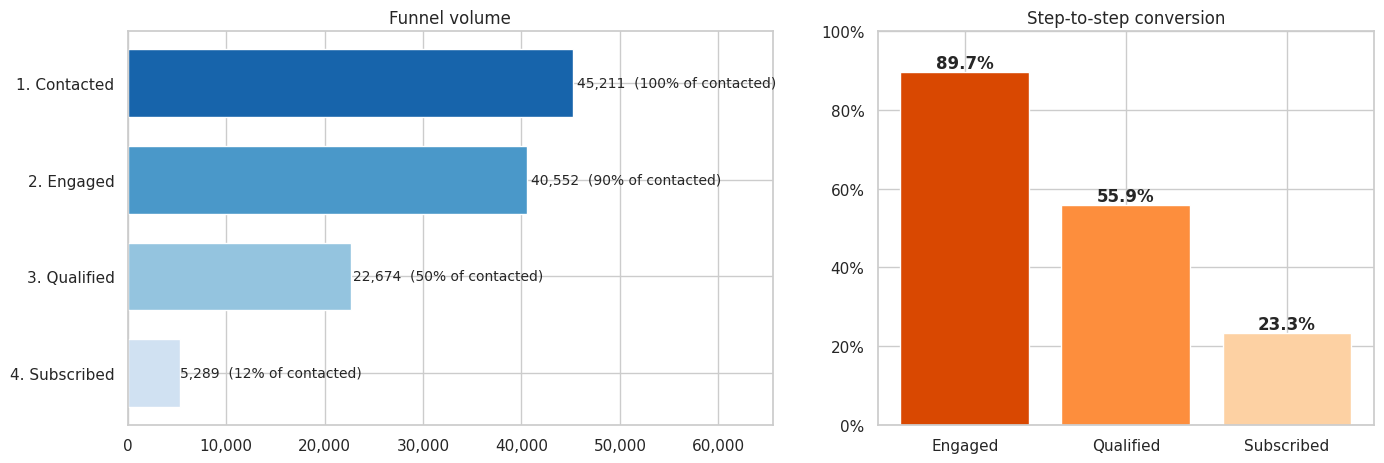

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios":[1.3,1]})
# funnel bars
y = np.arange(len(ft))[::-1]
ax[0].barh(y, ft.clients, color=sns.color_palette("Blues_r", len(ft)), height=.7)
for yi, r in zip(y, ft.itertuples()):
    txt = f"{r.clients:,.0f}  ({r._3:.0%} of contacted)"
    ax[0].text(r.clients*1.01, yi, txt, va="center", fontsize=10)
ax[0].set_yticks(y); ax[0].set_yticklabels(ft.stage); ax[0].set_xlim(0, ft.clients.max()*1.45)
ax[0].set_title("Funnel volume"); ax[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
# step conversion
sc = ft.dropna(subset=["step conversion"])
ax[1].bar(sc.stage.str.replace(r"^\d\. ","",regex=True), sc["step conversion"], color=sns.color_palette("Oranges_r",3))
for i, v in enumerate(sc["step conversion"]): ax[1].text(i, v+.01, f"{v:.1%}", ha="center", fontweight="bold")
ax[1].yaxis.set_major_formatter(PCT); ax[1].set_ylim(0,1); ax[1].set_title("Step-to-step conversion")
plt.tight_layout(); plt.show()

### Where do clients actually convert, by call length?
Because the funnel stages are duration-based, the call-length curve shows what the stage thresholds mean in practice.

,calls,subscribed,rate,share_of_calls,share_of_subs
duration_band,,,,,
0-30s,"2,010",5,0.2%,4.4%,0.1%
31-59s,"2,649",4,0.2%,5.9%,0.1%
60-179s,"17,878",692,3.9%,39.5%,13.1%
180-300s,"10,400","1,130",10.9%,23.0%,21.4%
300-600s,"8,484","1,625",19.2%,18.8%,30.7%
600s+,"3,790","1,833",48.4%,8.4%,34.7%


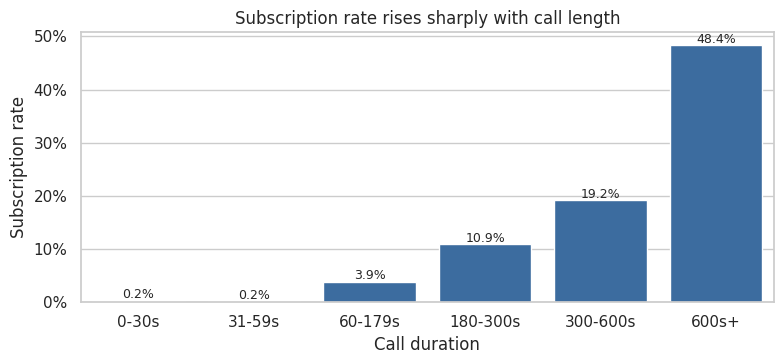

In [7]:
dur = (df.groupby("duration_band", observed=True)
         .agg(calls=("converted","size"), subscribed=("converted","sum"))
         .assign(rate=lambda x: x.subscribed/x.calls, share_of_calls=lambda x: x.calls/len(df),
                 share_of_subs=lambda x: x.subscribed/df.converted.sum()))
display(dur.style.format({"calls":"{:,.0f}","subscribed":"{:,.0f}","rate":"{:.1%}","share_of_calls":"{:.1%}","share_of_subs":"{:.1%}"}))

fig, ax = plt.subplots(figsize=(8,3.8))
sns.barplot(x=dur.index.astype(str), y=dur.rate, color="#2b6cb0", ax=ax)
ax.yaxis.set_major_formatter(PCT); ax.set_xlabel("Call duration"); ax.set_ylabel("Subscription rate")
ax.set_title("Subscription rate rises sharply with call length")
for i, v in enumerate(dur.rate): ax.text(i, v+.005, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

> **Caution – duration is an outcome-side signal.** Call length is only known *after* the call, and long calls are partly a *result* of interest rather than a cause of it (the dataset authors flag this for modelling). 
> Here it is used only to describe the funnel; the recommendations below focus on levers that are controllable *before* dialling (who, when, how, how often).

## 3. Compare performance: channels, campaigns, time periods

In [8]:
def segment_funnel(d, col, min_n=1):
    g = d.groupby(col, observed=True).agg(contacted=("s1_contacted","sum"), engaged=("s2_engaged","sum"),
                                         qualified=("s3_qualified","sum"), subscribed=("s4_subscribed","sum"))
    g = g[g.contacted >= min_n].copy()
    g["traffic→lead"]   = g.engaged / g.contacted
    g["lead→qualified"] = g.qualified / g.engaged
    g["qualified→cust"] = g.subscribed / g.qualified
    g["lead→customer"]  = g.subscribed / g.engaged
    g["end-to-end"]     = g.subscribed / g.contacted
    lo, hi = wilson(g.subscribed, g.contacted)
    g["CI low"], g["CI high"] = lo, hi
    base = d.s4_subscribed.mean()
    g["lift vs avg"] = g["end-to-end"] / base
    return g

def chi2_test(d, col, outcome="converted"):
    ct = pd.crosstab(d[col], d[outcome])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    return chi2, p, cramers_v

FMT = {"contacted":"{:,.0f}","engaged":"{:,.0f}","qualified":"{:,.0f}","subscribed":"{:,.0f}",
       "traffic→lead":"{:.1%}","lead→qualified":"{:.1%}","qualified→cust":"{:.1%}","lead→customer":"{:.1%}",
       "end-to-end":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}","lift vs avg":"{:.2f}x"}
SHOW = ["contacted","traffic→lead","lead→customer","end-to-end","CI low","CI high","lift vs avg"]

def report(d, col, order=None, sort=None, min_n=1, title=None):
    t = segment_funnel(d, col, min_n)
    if order is not None: t = t.reindex([o for o in order if o in t.index])
    if sort: t = t.sort_values(sort, ascending=False)
    chi2, p, v = chi2_test(d, col)
    print(f"{title or col}: chi² p-value = {p:.2g} | Cramér's V = {v:.3f}  ->  {'significant' if p<ALPHA else 'not significant'} association with subscription")
    display(t[SHOW].style.format(FMT))
    return t

### 3a. By channel (contact type)

In [9]:
ch = report(df, "contact", sort="end-to-end", title="Contact channel")

Contact channel: chi² p-value = 1.3e-225 | Cramér's V = 0.151  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
contact,,,,,,,
cellular,"29,285",91.4%,16.3%,14.9%,14.5%,15.3%,1.28x
telephone,"2,906",80.0%,16.8%,13.4%,12.2%,14.7%,1.15x
unknown,"13,020",88.0%,4.6%,4.1%,3.7%,4.4%,0.35x


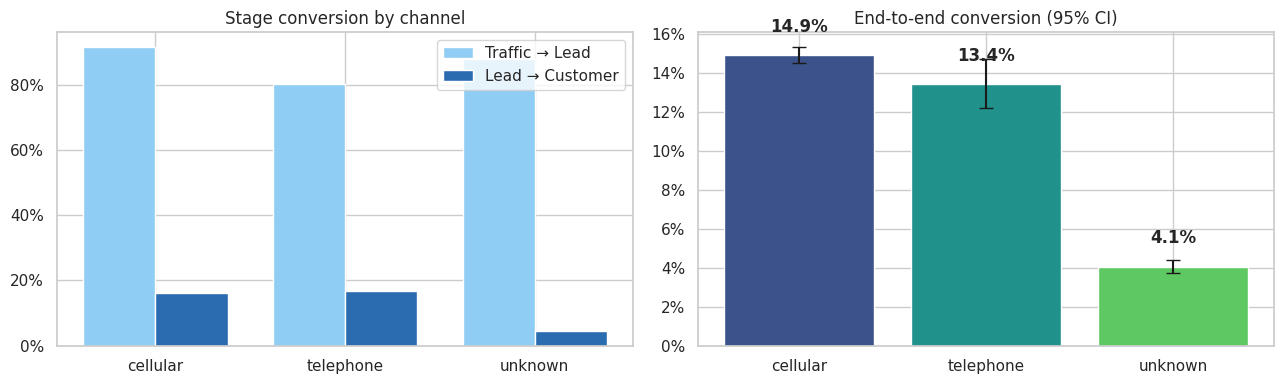

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(ch)); w = .38
ax[0].bar(x-w/2, ch["traffic→lead"], w, label="Traffic → Lead", color="#90cdf4")
ax[0].bar(x+w/2, ch["lead→customer"], w, label="Lead → Customer", color="#2b6cb0")
ax[0].set_xticks(x); ax[0].set_xticklabels(ch.index); ax[0].yaxis.set_major_formatter(PCT); ax[0].legend()
ax[0].set_title("Stage conversion by channel")
ax[1].bar(ch.index, ch["end-to-end"], color=sns.color_palette("viridis", len(ch)),
          yerr=[ch["end-to-end"]-ch["CI low"], ch["CI high"]-ch["end-to-end"]], capsize=5)
for i,v in enumerate(ch["end-to-end"]): ax[1].text(i, v+.012, f"{v:.1%}", ha="center", fontweight="bold")
ax[1].yaxis.set_major_formatter(PCT); ax[1].set_title("End-to-end conversion (95% CI)")
plt.tight_layout(); plt.show()

**Reading `contact = unknown`:** these records have no recorded channel. Check *when* they occur before drawing conclusions – they may be concentrated in a particular period (a data-capture issue) rather than being a genuine channel.

In [11]:
print("Share of 'unknown' channel by year:")
display((pd.crosstab(df.year, df.contact, normalize="index")).style.format("{:.1%}"))
print("Share of 'unknown' channel by month (all years):")
display((pd.crosstab(df.month, df.contact, normalize="index").reindex(MONTHS)).style.format("{:.1%}"))

Share of 'unknown' channel by year:


contact,cellular,telephone,unknown
year,,,
2008,49.1%,4.8%,46.0%
2009,91.2%,8.7%,0.0%
2010,80.2%,10.2%,9.6%


Share of 'unknown' channel by month (all years):


contact,cellular,telephone,unknown
month,,,
jan,90.2%,9.2%,0.6%
feb,89.2%,10.3%,0.5%
mar,87.4%,11.1%,1.5%
apr,93.0%,6.8%,0.2%
may,38.7%,3.3%,57.9%
jun,13.6%,1.5%,84.9%
jul,83.6%,12.4%,4.0%
aug,95.2%,3.9%,0.8%
sep,80.5%,11.4%,8.1%


In [12]:
# 'unknown' is concentrated in May-Jun 2008 (and a little in 2010) -> likely a logging gap, not a real channel.
# Like-for-like comparison: known channels only, then cellular vs telephone within each year.
known = df[df.contact != "unknown"]
print("Known channels only:")
display(segment_funnel(known, "contact")[SHOW].style.format(FMT))
ct = pd.crosstab(known.contact, known.converted)
print(f"Cellular vs telephone (known only): chi² p = {stats.chi2_contingency(ct)[1]:.3g}")
print("\nUnknown-channel conversion by period (is it low because of the channel, or because of when it was logged?):")
unk = df[df.contact == "unknown"].assign(window=lambda x: np.where((x.year==2008)&(x.month_num.isin([5,6])), "May-Jun 2008", "all other months"))
display(unk.groupby("window").agg(contacts=("converted","size"), rate=("converted","mean")).style.format({"contacts":"{:,.0f}","rate":"{:.1%}"}))
print("Compare: known-channel conversion in Jul-Aug 2008 (same mass-outreach period):",
      f"{df[(df.year==2008)&(df.month_num.isin([7,8]))&(df.contact!='unknown')].converted.mean():.1%}")

Known channels only:


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
contact,,,,,,,
cellular,"29,285",91.4%,16.3%,14.9%,14.5%,15.3%,1.01x
telephone,"2,906",80.0%,16.8%,13.4%,12.2%,14.7%,0.91x


Cellular vs telephone (known only): chi² p = 0.0321

Unknown-channel conversion by period (is it low because of the channel, or because of when it was logged?):


,contacts,rate
window,,
May-Jun 2008,"12,443",3.7%
all other months,577,12.3%


Compare: known-channel conversion in Jul-Aug 2008 (same mass-outreach period): 5.8%


### 3b. By campaign wave and previous-campaign outcome

In [13]:
po = report(df, "poutcome", sort="end-to-end", title="Previous campaign outcome")

Previous campaign outcome: chi² p-value = 0 | Cramér's V = 0.312  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
poutcome,,,,,,,
success,"1,511",98.1%,65.9%,64.7%,62.3%,67.1%,5.53x
other,"1,840",86.5%,19.3%,16.7%,15.1%,18.5%,1.43x
failure,"4,901",91.1%,13.8%,12.6%,11.7%,13.6%,1.08x
not previously contacted,"36,959",89.3%,10.3%,9.2%,8.9%,9.5%,0.78x


In [14]:
prev = report(df, "prev_contacted", title="Previously contacted vs. new prospect")

Previously contacted vs. new prospect: chi² p-value = 9.6e-277 | Cramér's V = 0.167  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
prev_contacted,,,,,,,
False,"36,954",89.3%,10.3%,9.2%,8.9%,9.5%,0.78x
True,"8,257",91.4%,25.2%,23.1%,22.2%,24.0%,1.97x


### 3c. By time period
Months are used as the "campaign wave" proxy. Note that calls are heavily concentrated in May–August.

In [15]:
mo = report(df, "month", order=MONTHS, title="Calendar month (all years)")

Calendar month (all years): chi² p-value = 0 | Cramér's V = 0.260  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
month,,,,,,,
jan,"1,403",93.4%,10.8%,10.1%,8.7%,11.8%,0.87x
feb,"2,649",87.5%,19.0%,16.6%,15.3%,18.1%,1.42x
mar,477,96.4%,53.9%,52.0%,47.5%,56.4%,4.44x
apr,"2,932",92.7%,21.2%,19.7%,18.3%,21.2%,1.68x
may,"13,766",89.5%,7.5%,6.7%,6.3%,7.1%,0.57x
jun,"5,341",85.5%,12.0%,10.2%,9.4%,11.1%,0.87x
jul,"6,895",89.9%,10.1%,9.1%,8.4%,9.8%,0.78x
aug,"6,247",91.3%,12.1%,11.0%,10.3%,11.8%,0.94x
sep,579,92.4%,50.3%,46.5%,42.4%,50.5%,3.97x


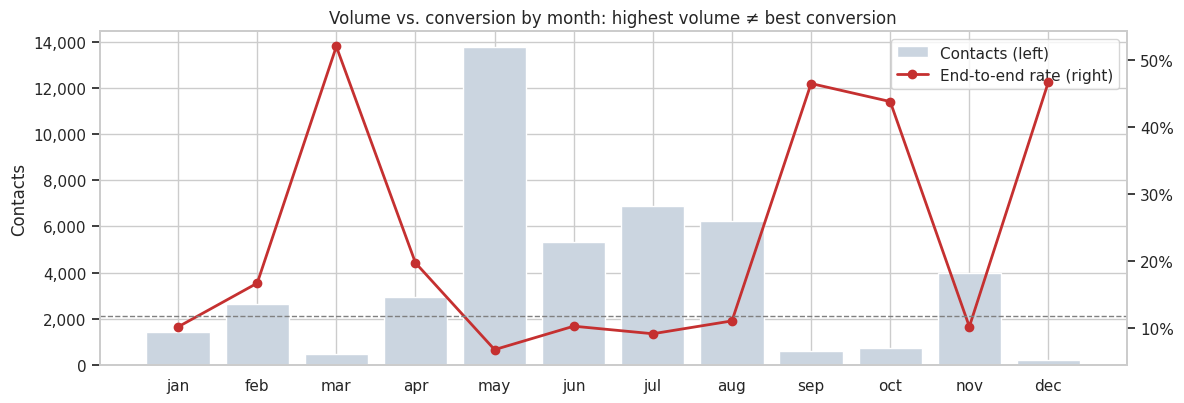

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(mo.index, mo.contacted, color="#cbd5e0", label="Contacts (left)")
ax.set_ylabel("Contacts"); ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(mo.index, mo["end-to-end"], marker="o", color="#c53030", lw=2, label="End-to-end rate (right)")
ax2.axhline(df.converted.mean(), ls="--", color="gray", lw=1); ax2.yaxis.set_major_formatter(PCT)
ax.set_title("Volume vs. conversion by month: highest volume ≠ best conversion")
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels(); ax.legend(h1+h2, l1+l2, loc="upper right")
plt.tight_layout(); plt.show()

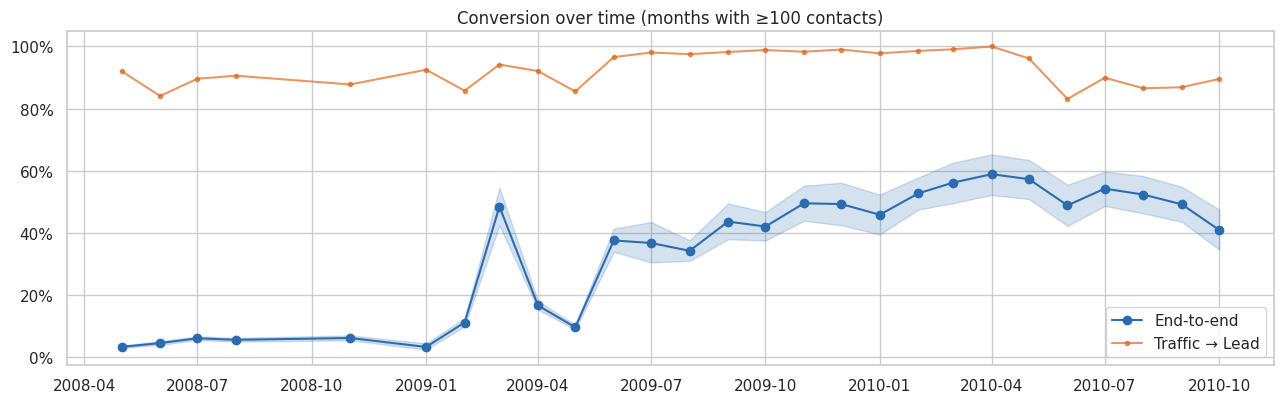

Year: chi² p-value = 0 | Cramér's V = 0.353  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
year,,,,,,,
2008,"27,729",89.3%,5.7%,5.1%,4.8%,5.3%,0.43x
2009,"14,862",89.8%,19.0%,17.1%,16.5%,17.7%,1.46x
2010,"2,620",92.9%,55.5%,51.6%,49.7%,53.5%,4.41x


In [17]:
# Month-by-month timeline (trend). Small months are noisy -> show CI band.
tl = segment_funnel(df, "period")
tl = tl[tl.contacted >= 100]
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(tl.index, tl["end-to-end"], marker="o", color="#2b6cb0", label="End-to-end")
ax.fill_between(tl.index, tl["CI low"], tl["CI high"], alpha=.2, color="#2b6cb0")
ax.plot(tl.index, tl["traffic→lead"], marker=".", color="#dd6b20", alpha=.7, label="Traffic → Lead")
ax.yaxis.set_major_formatter(PCT); ax.set_title("Conversion over time (months with ≥100 contacts)"); ax.legend()
plt.tight_layout(); plt.show()

yr = report(df, "year", title="Year")

### 3c-ii. Is it the *month*, or the *way the campaign was run*? (confounding check)
The best-converting months (Mar, Sep, Oct, Dec) are also the *lowest-volume* months. The monthly timeline suggests a regime change: 
mass calling in 2008 – mid-2009, then far fewer, warmer calls afterwards. If so, "seasonality" is mostly a campaign-design effect.

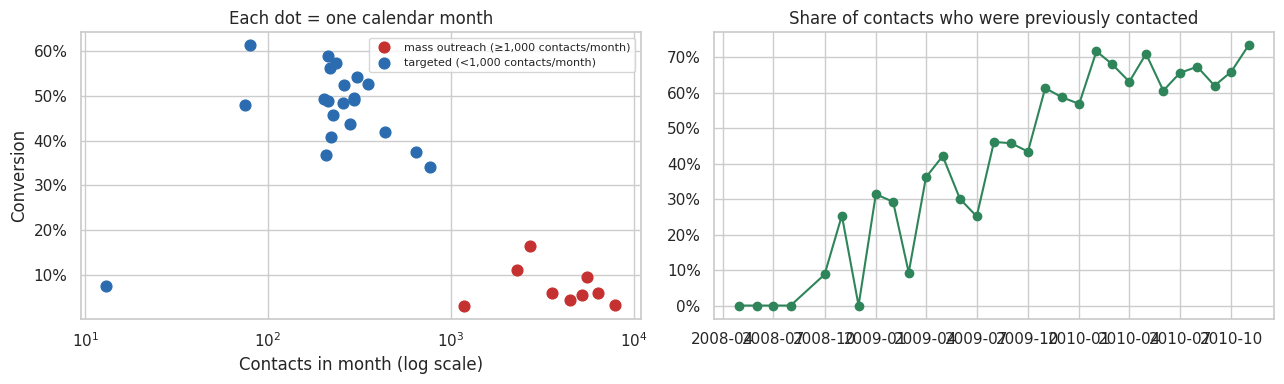

Funnel by regime:


,contacted,traffic→lead,lead→customer,end-to-end,lift vs avg
regime,,,,,
"mass outreach (≥1,000 contacts/month)","39,401",88.9%,7.5%,6.7%,0.57x
"targeted (<1,000 contacts/month)","5,810",95.1%,48.1%,45.8%,3.92x


Like-for-like (never previously contacted, channel recorded):


,contacted,traffic→lead,lead→customer,end-to-end,lift vs avg
regime,,,,,
"mass outreach (≥1,000 contacts/month)","21,394",89.0%,9.2%,8.2%,0.69x
"targeted (<1,000 contacts/month)","2,610",97.3%,43.9%,42.8%,3.58x


Calls per client by regime: {'mass outreach (≥1,000 contacts/month)': 2.9, 'targeted (<1,000 contacts/month)': 1.85}


In [18]:
vol = df.groupby("period").agg(contacts=("converted","size"), rate=("converted","mean"), prev_share=("prev_contacted","mean"))
vol["regime"] = np.where(vol.contacts >= 1000, "mass outreach (≥1,000 contacts/month)", "targeted (<1,000 contacts/month)")
df["regime"] = df.period.map(vol.regime)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for r, c in zip(vol.regime.unique(), ["#c53030", "#2b6cb0"]):
    v = vol[vol.regime == r]; ax[0].scatter(v.contacts, v.rate, label=r, s=60, color=c)
ax[0].set_xscale("log"); ax[0].yaxis.set_major_formatter(PCT); ax[0].set_xlabel("Contacts in month (log scale)")
ax[0].set_ylabel("Conversion"); ax[0].set_title("Each dot = one calendar month"); ax[0].legend(fontsize=8)
ax[1].plot(vol.index, vol.prev_share, marker="o", color="#2f855a"); ax[1].yaxis.set_major_formatter(PCT)
ax[1].set_title("Share of contacts who were previously contacted")
plt.tight_layout(); plt.show()

print("Funnel by regime:")
display(segment_funnel(df, "regime")[["contacted","traffic→lead","lead→customer","end-to-end","lift vs avg"]].style.format(FMT))

# Like-for-like: new prospects, known channel only
lfl = df[(~df.prev_contacted) & (df.contact != "unknown")]
print("Like-for-like (never previously contacted, channel recorded):")
display(segment_funnel(lfl, "regime")[["contacted","traffic→lead","lead→customer","end-to-end","lift vs avg"]].style.format(FMT))
print("Calls per client by regime:", df.groupby("regime").campaign.mean().round(2).to_dict())

**Interpretation.** The conversion gap between regimes remains large even for *new prospects on a known channel*, so it is not only a list-quality effect – it is consistent with 
smaller, more selective, higher-touch campaigns. Treat the month-level effects in 3c as **largely explained by campaign design**, not proof of seasonality. 
(Caveat: the public dataset may not include every call made in later months, so a sampling effect cannot be ruled out.)

### 3d. Attempts: how many calls does it take, and when does effort stop paying off?

In [19]:
at = report(df, "attempts_band", title="Number of contacts in this campaign")

Number of contacts in this campaign: chi² p-value = 7e-73 | Cramér's V = 0.088  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
attempts_band,,,,,,,
1,"17,544",91.6%,15.9%,14.6%,14.1%,15.1%,1.25x
2,"12,505",94.0%,11.9%,11.2%,10.7%,11.8%,0.96x
3,"5,521",91.1%,12.3%,11.2%,10.4%,12.1%,0.96x
4-5,"5,286",87.2%,9.9%,8.6%,7.9%,9.4%,0.74x
6-10,"3,159",76.8%,8.5%,6.5%,5.7%,7.4%,0.56x
11+,"1,196",55.9%,7.0%,3.9%,3.0%,5.2%,0.34x


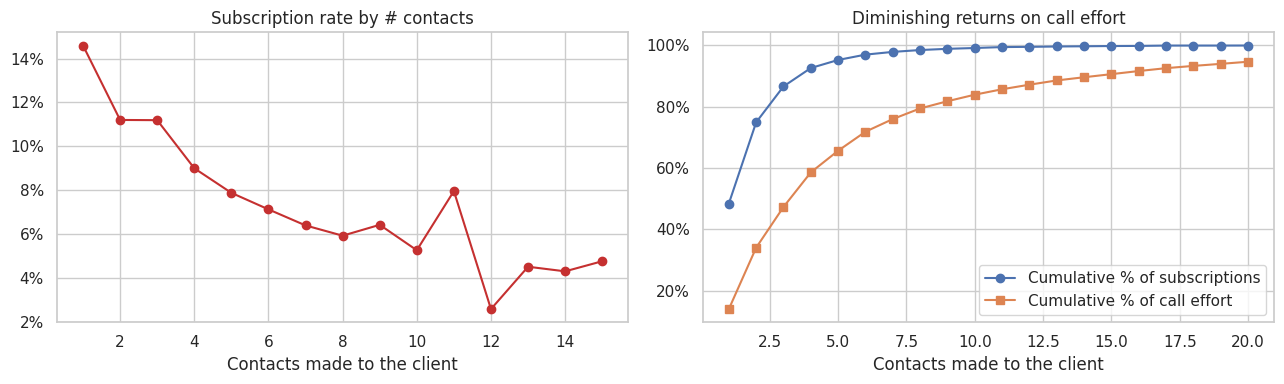

Clients needing more than 3 contacts: 21.3% of clients, 52.7% of all call attempts, but only 13.4% of subscriptions.


In [20]:
# Marginal return of each extra attempt. 'campaign' = total contacts for the client, so a client with
# campaign=k was reached on attempts 1..k. Conversion at k is the share of clients whose *last* call was k that subscribed.
byk = df.groupby("campaign").agg(clients=("converted","size"), subs=("converted","sum"))
byk["rate_final_attempt"] = byk.subs / byk.clients
byk["cum_subs_share"] = byk.subs.cumsum() / byk.subs.sum()
byk["cum_calls_share"] = (byk.clients * byk.index).cumsum() / (byk.clients * byk.index).sum()
top = byk.loc[:15]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(top.index, top.rate_final_attempt, marker="o", color="#c53030")
ax[0].yaxis.set_major_formatter(PCT); ax[0].set_xlabel("Contacts made to the client"); ax[0].set_title("Subscription rate by # contacts")
ax[1].plot(byk.index[:20], byk.cum_subs_share[:20], marker="o", label="Cumulative % of subscriptions")
ax[1].plot(byk.index[:20], byk.cum_calls_share[:20], marker="s", label="Cumulative % of call effort")
ax[1].yaxis.set_major_formatter(PCT); ax[1].set_xlabel("Contacts made to the client"); ax[1].legend(); ax[1].set_title("Diminishing returns on call effort")
plt.tight_layout(); plt.show()

k = 3
print(f"Clients needing more than {k} contacts: {(df.campaign>k).mean():.1%} of clients, "
      f"{(df.campaign[df.campaign>k]).sum()/df.campaign.sum():.1%} of all call attempts, "
      f"but only {df.converted[df.campaign>k].sum()/df.converted.sum():.1%} of subscriptions.")

## 4. Who converts? Audience segments

In [21]:
seg_results = {}
for col in ["job","age_band","education","marital","balance_band","housing","loan","default"]:
    seg_results[col] = report(df, col, sort="end-to-end", min_n=MIN_N)
    print()

job: chi² p-value = 3.3e-172 | Cramér's V = 0.136  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
job,,,,,,,
student,938,88.8%,32.3%,28.7%,25.9%,31.7%,2.45x
retired,"2,264",93.7%,24.3%,22.8%,21.1%,24.6%,1.95x
unemployed,"1,303",90.6%,17.1%,15.5%,13.6%,17.6%,1.33x
management,"9,458",89.9%,15.3%,13.8%,13.1%,14.5%,1.18x
admin.,"5,171",90.3%,13.5%,12.2%,11.3%,13.1%,1.04x
self-employed,"1,579",89.8%,13.2%,11.8%,10.3%,13.5%,1.01x
unknown,288,83.3%,14.2%,11.8%,8.6%,16.0%,1.01x
technician,"7,597",90.0%,12.3%,11.1%,10.4%,11.8%,0.95x
services,"4,154",89.9%,9.9%,8.9%,8.1%,9.8%,0.76x



age_band: chi² p-value = 7.6e-216 | Cramér's V = 0.149  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
age_band,,,,,,,
65+,810,98.5%,42.7%,42.1%,38.7%,45.5%,3.60x
18-24,809,91.5%,28.0%,25.6%,22.7%,28.7%,2.19x
55-64,"4,896",90.2%,14.5%,13.1%,12.2%,14.1%,1.12x
25-34,"14,204",90.2%,13.8%,12.5%,11.9%,13.0%,1.07x
35-44,"14,534",88.9%,10.9%,9.7%,9.2%,10.2%,0.83x
45-54,"9,958",89.0%,10.4%,9.3%,8.7%,9.9%,0.79x



education: chi² p-value = 1.6e-51 | Cramér's V = 0.073  ->  significant association with subscription


...

,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
housing,,,,,,,
no,"20,081",90.3%,18.5%,16.7%,16.2%,17.2%,1.43x
yes,"25,130",89.2%,8.6%,7.7%,7.4%,8.0%,0.66x



loan: chi² p-value = 1.7e-47 | Cramér's V = 0.068  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
loan,,,,,,,
no,"37,967",89.6%,14.1%,12.7%,12.3%,13.0%,1.08x
yes,"7,244",90.1%,7.4%,6.7%,6.1%,7.3%,0.57x



default: chi² p-value = 2.5e-06 | Cramér's V = 0.022  ->  significant association with subscription


,contacted,traffic→lead,lead→customer,end-to-end,CI low,CI high,lift vs avg
default,,,,,,,
no,"44,396",89.7%,13.2%,11.8%,11.5%,12.1%,1.01x
yes,815,89.2%,7.2%,6.4%,4.9%,8.3%,0.55x


,dimension,chi2,p_value,cramers_v
12,year,"5,639",0,0.353
1,poutcome,"4,392",0,0.312
2,month,"3,062",0,0.260
0,contact,"1,036",1.3e-225,0.151
5,age_band,"1,009",7.6e-216,0.149
9,housing,875,2.9e-192,0.139
4,job,836,3.3e-172,0.136
6,balance_band,430,1.1e-91,0.097
3,attempts_band,347,7e-73,0.088
7,education,239,1.6e-51,0.073


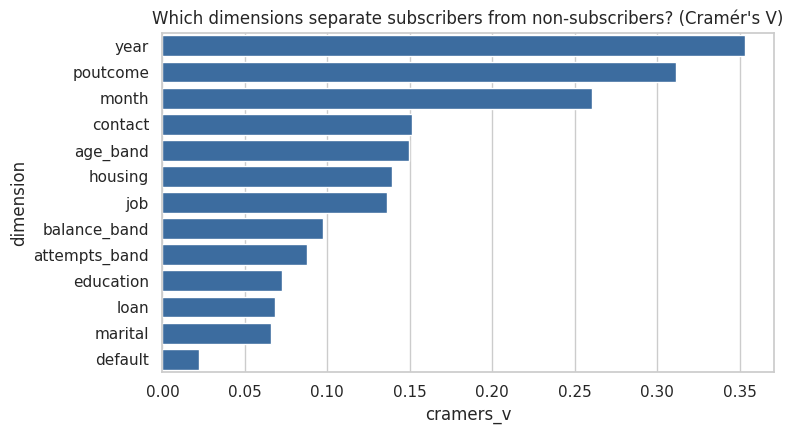

In [22]:
# Strength of association with subscription for every dimension (Cramér's V)
dims = ["contact","poutcome","month","attempts_band","job","age_band","balance_band","education","marital","housing","loan","default","year"]
assoc = pd.DataFrame([(d, *chi2_test(df, d)) for d in dims], columns=["dimension","chi2","p_value","cramers_v"]).sort_values("cramers_v", ascending=False)
display(assoc.style.format({"chi2":"{:,.0f}","p_value":"{:.2g}","cramers_v":"{:.3f}"}))
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=assoc, y="dimension", x="cramers_v", color="#2b6cb0", ax=ax)
ax.set_title("Which dimensions separate subscribers from non-subscribers? (Cramér's V)")
plt.tight_layout(); plt.show()

### 4b. Adjusted effects (multivariable check)
One-way tables can double-count overlapping effects (e.g. students are young *and* low-balance). A logistic regression using **only pre-call variables** 
(no `duration`) shows each factor's effect holding the others constant. Odds ratio > 1 = higher chance of subscribing.

Hold-out AUC (pre-call variables only): 0.790
References: ['job_blue-collar', 'marital_married', 'education_secondary', 'contact_cellular', 'poutcome_not previously contacted', 'regime_mass outreach (≥1,000 contacts/month)', 'housing_yes', 'loan_no', 'default_no']


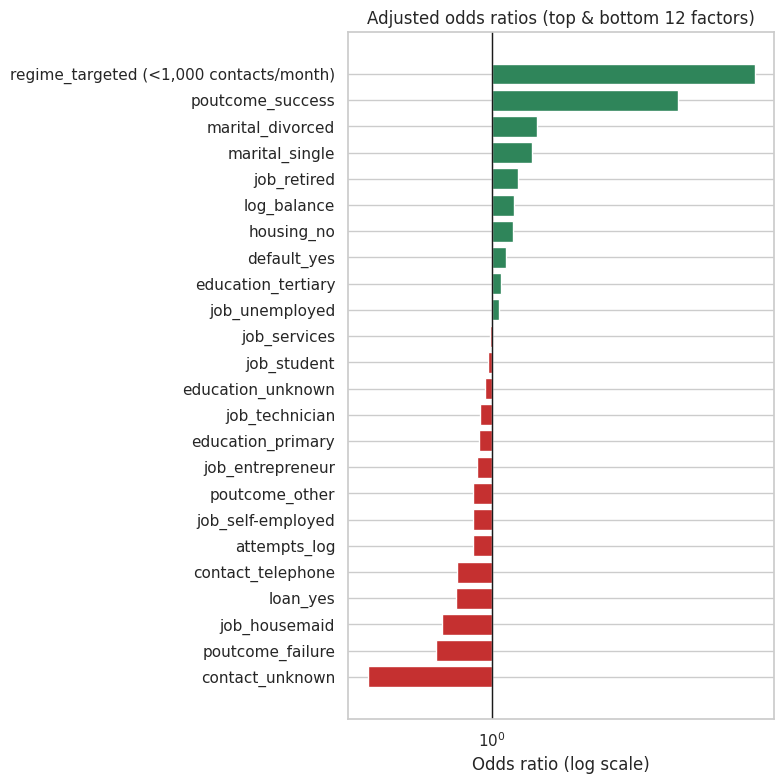

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

feat_cat = ["job","marital","education","contact","poutcome","regime","housing","loan","default"]
X = pd.get_dummies(df[feat_cat], drop_first=False).astype(float)
X["age_z"] = df.age; X["log_balance"] = np.sign(df.balance)*np.log1p(df.balance.abs()); X["attempts_log"] = np.log1p(df.campaign)
# reference levels = most common category per feature
ref = [f"{c}_{df[c].mode()[0]}" for c in feat_cat]
X = X.drop(columns=ref)
num = ["age_z","log_balance","attempts_log"]
sc = StandardScaler().fit(X[num]); X[num] = sc.transform(X[num])
Xtr, Xte, ytr, yte = train_test_split(X, df.converted, test_size=.25, random_state=42, stratify=df.converted)
lr = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, ytr)
print(f"Hold-out AUC (pre-call variables only): {roc_auc_score(yte, lr.predict_proba(Xte)[:,1]):.3f}")
orr = pd.Series(np.exp(lr.coef_[0]), index=X.columns).sort_values(ascending=False)
print("References:", ref)
fig, ax = plt.subplots(figsize=(8, 8))
sel = pd.concat([orr.head(12), orr.tail(12)])
ax.barh(sel.index, sel.values - 1, left=1, color=np.where(sel.values>1, "#2f855a", "#c53030"))
ax.axvline(1, color="k", lw=1); ax.set_xscale("log"); ax.invert_yaxis()
ax.set_title("Adjusted odds ratios (top & bottom 12 factors)"); ax.set_xlabel("Odds ratio (log scale)")
plt.tight_layout(); plt.show()

## 5. Where is the biggest opportunity?

In [24]:
# Opportunity sizing: if every under-performing segment reached the overall average (conservative), how many extra subscriptions?
# And a stretch target: the average of the top-performing comparable segments.
base = df.converted.mean()
rows = []
for col in ["contact","month","poutcome","job","age_band","balance_band","attempts_band","housing","loan","marital","education"]:
    t = segment_funnel(df, col, MIN_N)
    for seg, r in t.iterrows():
        rows.append(dict(dimension=col, segment=str(seg), contacted=r.contacted, rate=r["end-to-end"],
                         lift=r["lift vs avg"], subs=r.subscribed,
                         gap_to_avg=(base - r["end-to-end"]) * r.contacted))
opp = pd.DataFrame(rows)

print("Largest under-performing segments (extra subscriptions if raised to the overall average):")
display(opp.sort_values("gap_to_avg", ascending=False).head(10)
        .style.format({"contacted":"{:,.0f}","rate":"{:.1%}","lift":"{:.2f}x","subs":"{:,.0f}","gap_to_avg":"{:,.0f}"}))

print("High-converting segments with meaningful volume (candidates to scale):")
display(opp[opp.contacted >= 500].sort_values("lift", ascending=False).head(10)
        .style.format({"contacted":"{:,.0f}","rate":"{:.1%}","lift":"{:.2f}x","subs":"{:,.0f}","gap_to_avg":"{:,.0f}"}))

Largest under-performing segments (extra subscriptions if raised to the overall average):


,dimension,segment,contacted,rate,lift,subs,gap_to_avg
49,housing,yes,"25,130",7.7%,0.66x,"1,935","1,005"
2,contact,unknown,"13,020",4.1%,0.35x,530,993
16,poutcome,not previously contacted,"36,959",9.2%,0.78x,"3,386",938
11,month,may,"13,766",6.7%,0.57x,925,685
20,job,blue-collar,"9,732",7.3%,0.62x,708,430
53,marital,married,"27,214",10.1%,0.87x,"2,755",429
51,loan,yes,"7,244",6.7%,0.57x,484,363
37,balance_band,<=0,"7,280",6.9%,0.59x,502,350
33,age_band,35-44,"14,534",9.7%,0.83x,"1,404",296
56,education,secondary,"23,202",10.6%,0.90x,"2,450",264


High-converting segments with meaningful volume (candidates to scale):


,dimension,segment,contacted,rate,lift,subs,gap_to_avg
18,poutcome,success,"1,511",64.7%,5.53x,978,-801
14,month,sep,579,46.5%,3.97x,269,-201
13,month,oct,738,43.8%,3.74x,323,-237
36,age_band,65+,810,42.1%,3.60x,341,-246
27,job,student,938,28.7%,2.45x,269,-159
31,age_band,18-24,809,25.6%,2.19x,207,-112
24,job,retired,"2,264",22.8%,1.95x,516,-251
3,month,apr,"2,932",19.7%,1.68x,577,-234
48,housing,no,"20,081",16.7%,1.43x,"3,354","-1,005"
17,poutcome,other,"1,840",16.7%,1.43x,307,-92


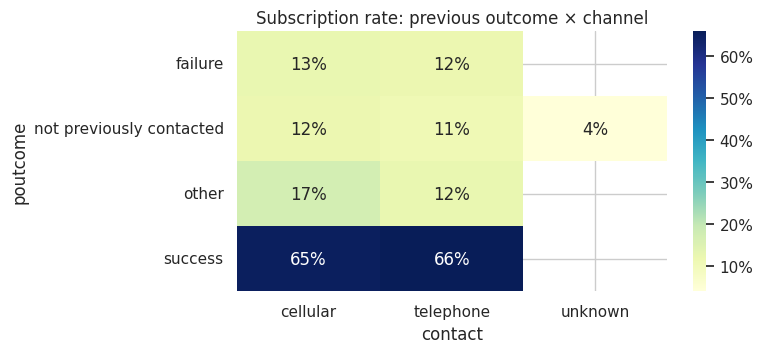

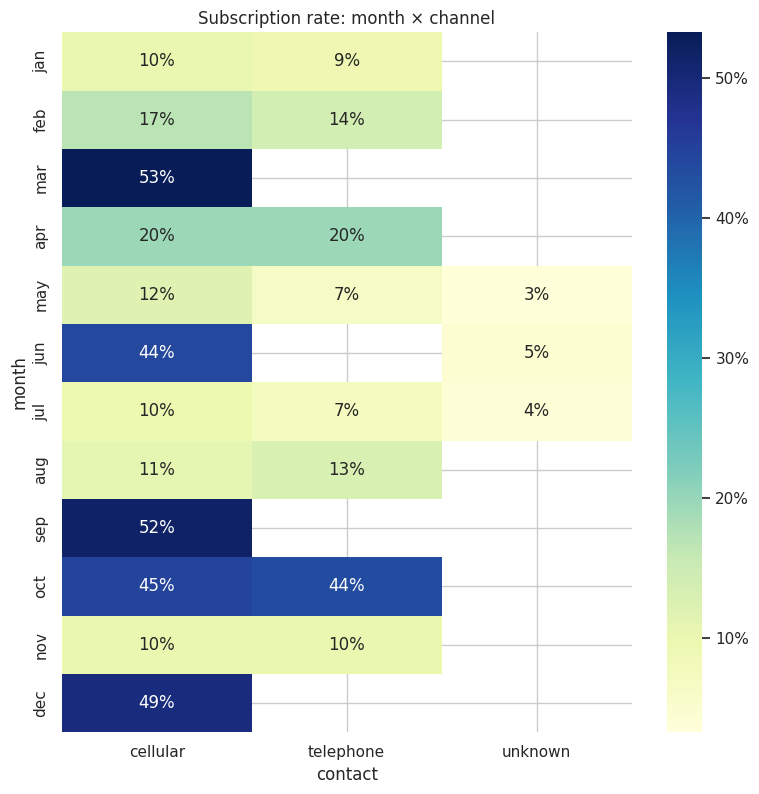

In [25]:
# Practical combination: channel x previous outcome, and month x channel (heatmaps; cells with <100 contacts blanked)
def heat(d, r, c, order_r=None, order_c=None, title=""):
    n  = pd.crosstab(d[r], d[c])
    rt = pd.crosstab(d[r], d[c], values=d.converted, aggfunc="mean")
    rt = rt.where(n >= 100)
    if order_r: rt = rt.reindex(order_r)
    if order_c: rt = rt[[x for x in order_c if x in rt.columns]]
    fig, ax = plt.subplots(figsize=(8, 0.55*len(rt)+1.5))
    sns.heatmap(rt, annot=True, fmt=".0%", cmap="YlGnBu", cbar_kws={"format":PCT}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

heat(df, "poutcome", "contact", title="Subscription rate: previous outcome × channel")
heat(df, "month", "contact", order_r=MONTHS, title="Subscription rate: month × channel")

In [26]:
# Simple "what-if" scenario modelling (transparent arithmetic, not a forecast)
n = len(df); subs = df.converted.sum()

# Scenario A: cap attempts at 3 -> keep subscriptions of clients with <=3 contacts, redeploy saved calls at the average cost per sub
over = df[df.campaign > 3]
saved_calls = (over.campaign - 3).sum()
calls_per_sub = df.campaign.sum() / subs
print(f"A) Capping at 3 contacts frees ~{saved_calls:,.0f} call attempts ({saved_calls/df.campaign.sum():.1%} of effort) "
      f"and forgoes at most {over.converted.sum():,} subscriptions ({over.converted.sum()/subs:.1%}).")
print(f"   At the current average of {calls_per_sub:.0f} calls per subscription, redeploying them could win back ~{saved_calls/calls_per_sub:,.0f} subs.")

# Scenario B: stop the least productive effort - contacts to the weakest segments (housing loan AND personal loan AND balance <= 0)
low = df[(df.housing=="yes") & (df.loan=="yes") & (df.balance<=0)]
print(f"B) 'Triple-negative' segment (housing loan + personal loan + balance<=0): {len(low):,} contacts "
      f"({len(low)/n:.1%}) converting at {low.converted.mean():.1%} vs {base:.1%} overall. De-prioritising it frees "
      f"{low.campaign.sum():,} call attempts for the cost of {low.converted.sum():,} subscriptions.")

# Scenario C: lift the 'previously contacted but not successful' pool
pf = df[df.poutcome.isin(["failure","other"])]
print(f"C) {len(pf):,} previously-contacted non-converters convert at {pf.converted.mean():.1%} vs {df[~df.prev_contacted].converted.mean():.1%} for brand-new prospects (raw).")
print("   Caution: the adjusted model in 4b shows prior 'failure' clients are NOT warmer once campaign regime is controlled - the raw gap is mostly a campaign-design effect.")

A) Capping at 3 contacts frees ~36,916 call attempts (29.5% of effort) and forgoes at most 709 subscriptions (13.4%).
   At the current average of 24 calls per subscription, redeploying them could win back ~1,563 subs.
B) 'Triple-negative' segment (housing loan + personal loan + balance<=0): 1,089 contacts (2.4%) converting at 6.2% vs 11.7% overall. De-prioritising it frees 3,154 call attempts for the cost of 67 subscriptions.
C) 6,741 previously-contacted non-converters convert at 13.7% vs 9.2% for brand-new prospects (raw).
   Caution: the adjusted model in 4b shows prior 'failure' clients are NOT warmer once campaign regime is controlled - the raw gap is mostly a campaign-design effect.


## 6. Findings & recommendations

> Figures below come from the full file (`bank-full.csv`, 45,211 contacts) with the default stage thresholds (60 s / 180 s). Re-run the notebook after changing the Config cell; the tables above are always the source of truth.

### What the data says

| # | Finding | Evidence |
|---|---|---|
| 1 | **Reaching people is not the problem; converting the conversation is.** | 89.7% of contacts reach a ≥60 s call, but only 13.0% of those subscribe. Biggest leaks: Engaged→Qualified loses 44% and Qualified→Subscribed loses a further 77%. Calls under 60 s almost never convert (9 of 4,659). |
| 2 | **Conversion is driven by call depth.** | 600 s+ calls are 8% of calls but 35% of subscriptions (48% conversion). Duration is partly an *outcome* of interest, so this is a diagnostic, not a lever on its own. |
| 3 | **Persistence has sharply diminishing returns.** | Conversion falls from ~15% (1 contact) to ~9% (4-5), ~7% (6-10) and ~4% (11+). Clients needing >3 contacts consume 52.7% of call attempts but yield 13.4% of subscriptions. |
| 4 | **Prior success is the strongest warm signal.** | Previous-campaign successes convert at 65% (n=1,511, only 3.3% of contacts) vs 9% for new prospects. Adjusted odds ratio ≈ 3.8. |
| 5 | **Campaign design matters more than calendar month.** | From mid-2009 volume dropped to a few hundred contacts/month and conversion rose to ~46% (vs ~7% in mass-outreach months). The gap persists for like-for-like new prospects on a known channel (43% vs 8%), with fewer calls per client (1.85 vs 2.9). The high-converting months (Mar, Sep, Oct, Dec) are low-volume months, so this is largely **not** seasonality. |
| 6 | **"Unknown" channel is a data-capture gap, not a channel.** | 12,443 of its 13,020 contacts are May–Jun 2008 (4% conversion, same as other mass-outreach months). Cellular (14.9%) vs telephone (13.4%) differ only slightly. |
| 7 | **Audience matters.** | Higher conversion: no housing loan (17% vs 8%), no personal loan (13% vs 7%), balance €1.5k+ (15–17% vs 7% for ≤€0), retired (23%), 65+ (42%), students (29%), single/divorced. Lowest: blue-collar (7%), balance ≤ 0. Some segment effects (e.g. students) shrink after adjustment because they overlap with age and campaign regime. |

### Recommendations (ordered by expected impact ÷ effort)

1. **Prioritise lists by propensity before dialling.** A logistic model built *only* on pre-call fields reaches AUC ≈ 0.79. Score the list and call the top deciles first; start with prior-success clients (65%), then no-housing-loan / no-personal-loan clients with a balance above ~€1.5k, retirees and 65+. 
   *Measure:* conversion and calls-per-subscription for scored vs. unscored lists (hold out ~10% as a control).
2. **Cap attempts at ~3 and move the rest to a lower-cost nurture channel** (SMS/email/inbound offer). This frees ~37k call attempts (29.5% of effort) at a cost of at most ~709 subscriptions (13.4%); redeployed at current productivity that effort could plausibly recover a similar number or more (an upper-bound illustration, not a forecast). 
   *Measure:* A/B test cap-at-3 vs. current rules on matched lists.
3. **Make the targeted, smaller-batch campaign design the default and test it properly.** Fewer, warmer, lower-touch campaigns converted ~5x better. Because this comparison is observational (and the public file may not contain every later call), run a controlled test: same audience, targeted vs. broad outreach. 
4. **Fix the call itself.** 44% of engaged leads never reach a real conversation and 77% of qualified conversations don't close. Review calls in the 60–180 s band, tighten the opening 60 s (relevance to the client's balance/loan situation), standardise objection handling and a clear close, and add an explicit call disposition (interested / callback / refused / not now). 
   *Measure:* Engaged→Qualified and Qualified→Subscribed rates by agent and script.
5. **Do not assume past "failures" are warm leads.** Raw conversion looks better (13.7% vs 9.2% for new prospects), but this disappears once campaign regime is controlled (adjusted odds ratio < 1). Only previous *successes* are reliably warm.
6. **Stop mass-calling the weakest pockets.** E.g. clients with both a housing and personal loan and a zero/negative balance convert at ~6%. Use cheaper channels or exclude them when capacity is tight.
7. **Fix tracking so the funnel can be measured properly.** Always log channel (cellular vs. landline), add a campaign ID, lead source, call timestamps, call disposition, agent and cost per call. Without these, "traffic → lead → customer" can only be approximated from call duration, and channel/campaign ROI can't be calculated.

### Limitations
- Stages 2–3 are **duration-based proxies**; replace them with real lead statuses if your CRM has them.
- All comparisons are **observational**. Adjusted estimates reduce but do not remove confounding; verify the top actions with A/B tests.
- `duration` is not known before a call and is excluded from the targeting model by design.
- Year was reconstructed from file ordering; the dataset ends Nov 2010 and early/late months have few records.

In [27]:
# Export cleaned data and key tables for BI tools / follow-up work
out = Path("funnel_outputs"); out.mkdir(exist_ok=True)
df.to_csv(out / "bank_clean.csv", index=False)
with pd.ExcelWriter(out / "funnel_summary.xlsx") as xw:
    ft.to_excel(xw, sheet_name="funnel", index=False)
    for name, t in {"channel":ch, "poutcome":po, "month":mo, "attempts":at, "year":yr}.items():
        t.to_excel(xw, sheet_name=name)
    opp.sort_values("gap_to_avg", ascending=False).to_excel(xw, sheet_name="opportunities", index=False)
print("Saved to", out.resolve())

Saved to /home/claude/funnel_outputs
